In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Abrir a base de dados

tabela = pd.read_csv("data/salaries.csv")

In [13]:
# Visualizar a base de dados
    # Entender as informações disponíveis

print(tabela.head())
print(tabela.info())
print(tabela.describe())

   work_year experience_level employment_type                       job_title  \
0       2021               MI              FT                  Data Scientist   
1       2021               MI              FT                 BI Data Analyst   
2       2020               MI              FT                  Data Scientist   
3       2021               MI              FT                     ML Engineer   
4       2022               SE              FT  Lead Machine Learning Engineer   

     salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
0  30400000             CLP          40038                 CL           100   
1  11000000             HUF          36259                 HU            50   
2  11000000             HUF          35735                 HU            50   
3   8500000             JPY          77364                 JP            50   
4   7500000             INR          95386                 IN            50   

  company_location company_size  
0   

In [14]:
   # Possíveis problemas/erros
print(tabela.isnull().sum())
print(tabela.duplicated().sum())
print(tabela["salary_in_usd"].describe())
print(tabela[tabela["job_title"] == "AI Architect"].sort_values("salary_in_usd", ascending=False))

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64
5711
count     14838.000000
mean     149874.718763
std       69009.181349
min       15000.000000
25%      102000.000000
50%      141300.000000
75%      185900.000000
max      800000.000000
Name: salary_in_usd, dtype: float64
       work_year experience_level employment_type     job_title  salary  \
66          2024               MI              FT  AI Architect  800000   
102         2024               SE              FT  AI Architect  449000   
257         2023               SE              FT  AI Architect  330000   
258         2023               SE              FT  AI Architect  330000   
259         2023               SE              FT  AI Architect  330000   
260         2023               SE              F

In [ ]:
# Análise inicial
import plotly.express as px

#Distribuição de salários por nível de experiência
print(tabela["experience_level"].value_counts())
fig = px.box(tabela, x = "experience_level", y = "salary_in_usd", title = "Distribuição de Salários por Nível de Experiência", labels={"salary_in_usd": "Salário (USD)", "experience_level": "Nível de Experiência"})
fig.show()

experience_level
SE    9696
MI    3553
EN    1148
EX     441
Name: count, dtype: int64


In [16]:
# Análise detalhada

# Top cargos mais bem pagos
salario_cargo = (tabela.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(10).reset_index())
fig = px.bar(salario_cargo, x= "salary_in_usd", y="job_title", orientation="h", title="Top 10 Cargos Mais Bem Pagos", labels={"salary_in_usd": "Salário Médio (USD)", "job_title": "Cargo"})
fig.show()

# O gráfico mostra que o cargo de Gerente de Engenharia Analítica é o cargo mais bem pago, com uma média de US$400k.

In [17]:
# Salário por tamanho da empresa
print(tabela["company_size"].value_counts())
fig = px.box(tabela, x= "company_size", y= "salary_in_usd", title="Distribuição de Salários por Tamanho da Empresa", labels= {"company_size": "Tamanho da Empresa", "salary_in_usd": "Salário (USD)"})
fig.show()

# Nessa análise, as empresas de tamanho M possuem os maiores salários, e são as com maiores quantidades de registros.

company_size
M    13674
L      983
S      181
Name: count, dtype: int64


In [18]:
# Tratar e preparar a base de dados para a IA

x = tabela[["experience_level", "employment_type", "job_title", "company_location", "remote_ratio", "company_size"]]
y= tabela["salary_in_usd"]

x = pd.get_dummies(x)

In [34]:
# Separar treino e teste

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.3)

In [35]:
# Importar modelo
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

#Criar modelo
modelo_random_forest = RandomForestClassifier()
modelo_neighbors = KNeighborsClassifier()

#Treinar modelo
modelo_random_forest.fit(x_train, y_train)
modelo_neighbors.fit(x_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
# Fazer previsões
previsao_forest = modelo_random_forest.predict(x_test)
previsao_knn = modelo_neighbors.predict(x_test)

#Comparar com y_test
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, previsao_forest))
print(accuracy_score(y_test, previsao_knn))

# Melhor modelo: Random Forest

0.04582210242587601
0.03032345013477089


In [43]:
# Avaliar o modelo

from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, previsao_forest))
print("R2:", r2_score(y_test, previsao_forest))

MAE: 46807.18845462713
R2: 0.028528925282810036


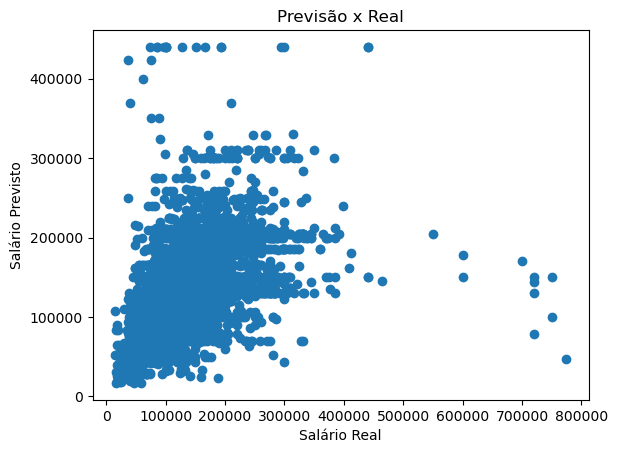

In [40]:
import matplotlib.pyplot as plt

plt.scatter(y_test, previsao_forest)
plt.xlabel("Salário Real")
plt.ylabel("Salário Previsto")
plt.title("Previsão x Real")

plt.show()

# Conclusão
O modelo apresentou MAE de aproximadamente 40 mil USD, indicando que a previsão média difere do valor real nesse intervalo.
O R² de 0.31 indica que o modelo explica cerca de 31% da variação dos salários, sugerindo que outros fatores não presentes no dataset influenciam significativamente os valores.